# Análisis Exploratorio de Datos — Maestro de Materiales M402
## Tipo ZMAF · Corporación Multi Inversiones · Mayo 2026
---
**Proyecto:** Asistente Inteligente de Gestión de Materiales SAP  
**Equipo:** Alejandra Alvarado · Rudy Osorio · Erick Marroquin  
**Programa:** MBIA · Universidad del Valle de Guatemala  
**Fecha corte datos:** 29 de mayo 2026

### Objetivo del EDA
Caracterizar el catálogo de tipo ZMAF del mandante 402 para:
1. Cuantificar el problema de duplicidad real
2. Identificar patrones de descripción y nomenclatura
3. Detectar materiales mal categorizados
4. Fundamentar la selección de modelos de IA para el proyecto final


In [1]:
# ── Resolucion de rutas (agregado al importar al repositorio GAMMA) ──────
# Localiza data/xlsx tanto dentro del contenedor Jupyter como en ejecucion local,
# sin importar la profundidad del notebook respecto de lab/.
import os

def _find_data_dir():
    if os.path.isdir('/home/jovyan/work/data/xlsx'):
        return '/home/jovyan/work/data/xlsx'
    d = os.path.abspath('.')
    for _ in range(6):
        cand = os.path.join(d, 'data', 'xlsx')
        if os.path.isdir(cand):
            return cand
        d = os.path.dirname(d)
    raise FileNotFoundError('No se encontro el directorio data/xlsx')

DATA_DIR = _find_data_dir()
FIG_DIR  = os.path.join(os.path.abspath('.'), 'figuras')
os.makedirs(FIG_DIR, exist_ok=True)
print('DATA_DIR:', DATA_DIR)
print('FIG_DIR :', FIG_DIR)


DATA_DIR: /Users/menene/code/www/mbia_gamma/lab/data/xlsx
FIG_DIR : /Users/menene/code/www/mbia_gamma/lab/notebooks/eda/figuras


## 1. Carga y Perfil Inicial del Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# Paleta corporativa CMI
CMI_VERDE  = '#1A6635'
CMI_CLARO  = '#D6EFE0'
CMI_ORO    = '#C9A84C'
CMI_GRIS   = '#4A4A4A'
CMI_ROJO   = '#C0392B'

TIPO = 'ZMAF'
XLSX = 'ZMAF_29MAY26.xlsx'

# ── Carga de archivos ────────────────────────────────────────────────────
df = pd.read_excel(os.path.join(DATA_DIR, XLSX))
df_cls = pd.read_excel(os.path.join(DATA_DIR, 'Clases de material DEN.xlsx'))

# Renombrar columna duplicada si existe
if 'Texto breve de material.1' in df.columns:
    df = df.rename(columns={'Texto breve de material.1': 'Texto_breve_2'})

print(f'Registros {TIPO}:       {len(df):,}')
print(f'Columnas:              {df.columns.tolist()}')
print(f'Clases en catálogo:    {len(df_cls):,}')
df.head(3)


Registros ZMAF:       80
Columnas:              ['Material', 'PB nivel mandante', 'Tipo material', 'Grupo de artículos', 'Unidad medida base', 'Info fabr./insp.', 'Denom.estándar', 'Texto breve de material', 'Texto_breve_2']
Clases en catálogo:    1,539


,Material,PB nivel mandante,Tipo material,Grupo de artículos,Unidad medida base,Info fabr./insp.,Denom.estándar,Texto breve de material,Texto_breve_2
0,17500003,NaN,ZMAF,EQU341000,KIT,41111600.0,13912.0,INSTRUMENTO:MEDICION:DFX-8-EXP;DAKOTA,INSTRUMENTO:MEDICION:DFX-8-EXP;DAKOTA
1,17500011,NaN,ZMAF,EQU341000,UN,40101701.0,9469.0,AIRE:ACONDICIONADO;12000BTU,AIRE:ACONDICIONADO;12000BTU
2,17500012,NaN,ZMAF,EQU341000,UN,40101701.0,9469.0,AIRE:ACONDICIONADO;18000BTU,AIRE:ACONDICIONADO;18000BTU


## 2. Completitud de Campos Críticos
> Porcentaje de nulos por columna. Los vacíos son exactamente el tipo de error que el asistente inteligente prevendrá.


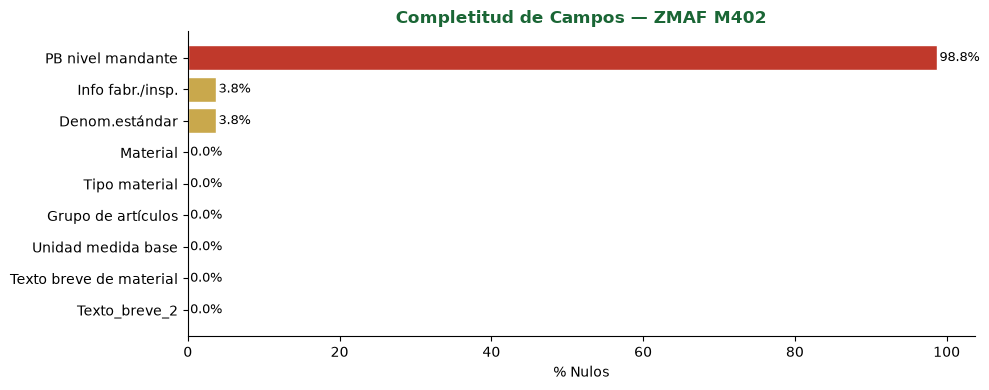

PB nivel mandante          98.75
Info fabr./insp.            3.75
Denom.estándar              3.75
Material                    0.00
Tipo material               0.00
Grupo de artículos          0.00
Unidad medida base          0.00
Texto breve de material     0.00
Texto_breve_2               0.00


In [3]:
nulos = df.isnull().mean().sort_values(ascending=False) * 100
fig, ax = plt.subplots(figsize=(10, 4))
colores = [CMI_ROJO if v > 10 else CMI_ORO if v > 0 else CMI_VERDE for v in nulos.values]
bars = ax.barh(nulos.index[::-1], nulos.values[::-1], color=colores[::-1], edgecolor='white')
for bar, val in zip(bars, nulos.values[::-1]):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
ax.set_xlabel('% Nulos')
ax.set_title(f'Completitud de Campos — {TIPO} M402', fontweight='bold', color=CMI_VERDE)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f'fig1_completitud_{TIPO}.png'), dpi=150, bbox_inches='tight')
plt.show()
print(nulos.to_string())


## 3. Análisis de Duplicados Exactos

Duplicados exactos (por texto breve): 4 registros / 2 grupos
Porcentaje del catálogo:              5.0%


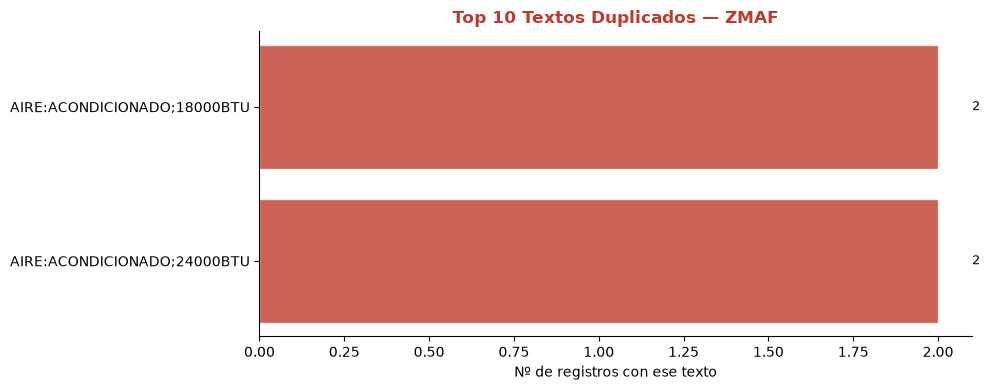

In [4]:
# Detectar columna de texto breve
col_texto = 'Texto breve de material' if 'Texto breve de material' in df.columns else df.columns[-1]

dup_mask = df.duplicated(subset=[col_texto], keep=False)
dup_df = df[dup_mask]
n_dup = dup_mask.sum()
n_grupos = df[dup_mask].groupby(col_texto).ngroups

print(f'Duplicados exactos (por texto breve): {n_dup:,} registros / {n_grupos:,} grupos')
print(f'Porcentaje del catálogo:              {n_dup/len(df)*100:.1f}%')

top_dup = (df[dup_mask]
           .groupby(col_texto)['Material'].count()
           .sort_values(ascending=False).head(10))

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(top_dup.index[::-1], top_dup.values[::-1], color=CMI_ROJO, alpha=0.8, edgecolor='white')
for i, val in enumerate(top_dup.values[::-1]):
    ax.text(val + 0.1, i, str(val), va='center', fontsize=9)
ax.set_title(f'Top 10 Textos Duplicados — {TIPO}', fontweight='bold', color=CMI_ROJO)
ax.set_xlabel('Nº de registros con ese texto')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f'fig2_duplicados_{TIPO}.png'), dpi=150, bbox_inches='tight')
plt.show()


## 4. Distribución por Grupo de Artículos

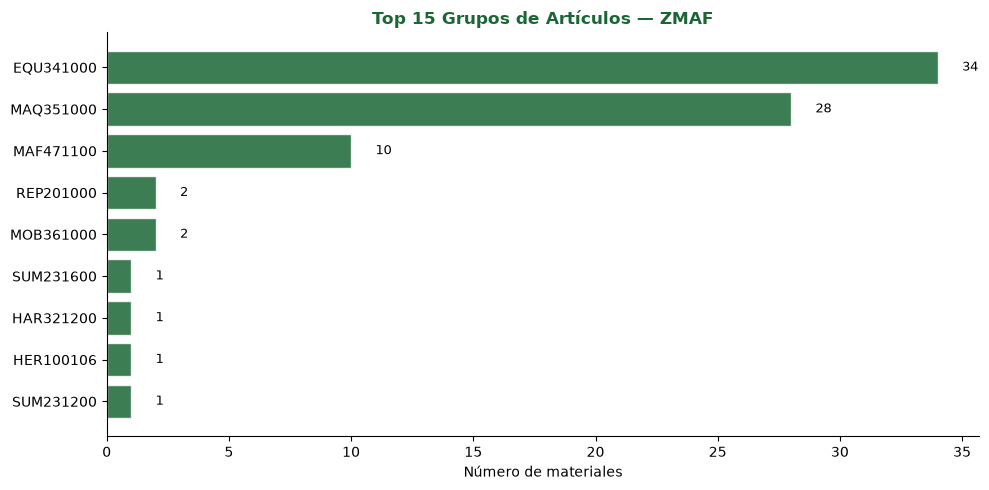

Grupo de artículos
EQU341000    34
MAQ351000    28
MAF471100    10
REP201000     2
MOB361000     2
SUM231600     1
HAR321200     1
HER100106     1
SUM231200     1


In [5]:
if 'Grupo de artículos' in df.columns:
    col_grp = 'Grupo de artículos'
elif 'Grupo de Artículos' in df.columns:
    col_grp = 'Grupo de Artículos'
else:
    col_grp = None

if col_grp:
    grp = df[col_grp].value_counts().head(15)
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(grp.index[::-1], grp.values[::-1], color=CMI_VERDE, alpha=0.85, edgecolor='white')
    for i, val in enumerate(grp.values[::-1]):
        ax.text(val + 1, i, str(val), va='center', fontsize=9)
    ax.set_title(f'Top 15 Grupos de Artículos — {TIPO}', fontweight='bold', color=CMI_VERDE)
    ax.set_xlabel('Número de materiales')
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f'fig3_grupos_{TIPO}.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print(grp.to_string())
else:
    print('Columna Grupo de artículos no encontrada')


## 5. Distribución por Unidad de Medida Base

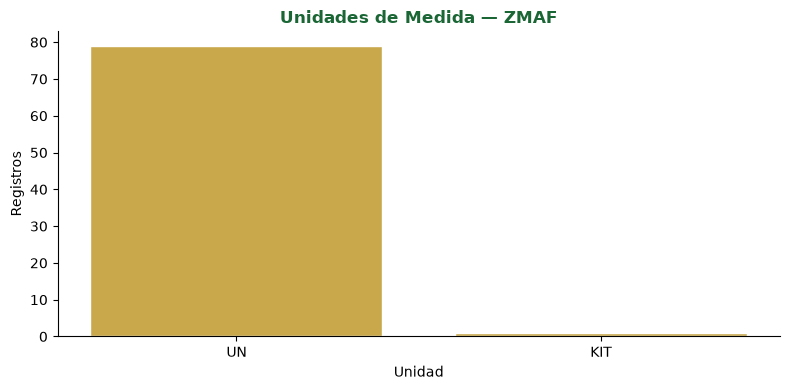

Unidad medida base
UN     79
KIT     1


In [6]:
if 'Unidad medida base' in df.columns:
    col_um = 'Unidad medida base'
elif 'Unidad de medida base' in df.columns:
    col_um = 'Unidad de medida base'
else:
    col_um = None

if col_um:
    um = df[col_um].value_counts()
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(um.index, um.values, color=CMI_ORO, edgecolor='white')
    ax.set_xlabel('Unidad')
    ax.set_ylabel('Registros')
    ax.set_title(f'Unidades de Medida — {TIPO}', fontweight='bold', color=CMI_VERDE)
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f'fig4_unidades_{TIPO}.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print(um.to_string())


## 6. Materiales Bloqueados (PB = X)

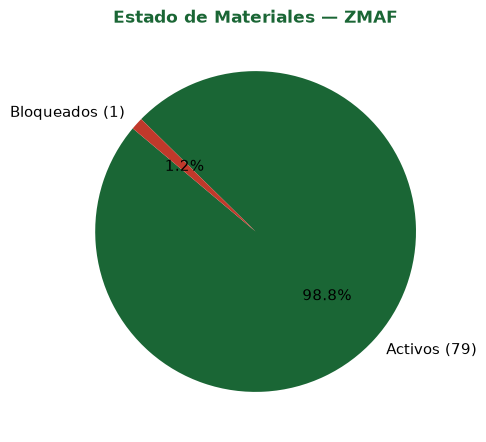

Bloqueados: 1  (1.2%)


In [7]:
col_pb = [c for c in df.columns if 'PB' in c or 'nivel' in c.lower()]
if col_pb:
    c = col_pb[0]
    bloqueados = (df[c] == 'X').sum()
    activos    = len(df) - bloqueados
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.pie([activos, bloqueados],
           labels=[f'Activos ({activos:,})', f'Bloqueados ({bloqueados:,})'],
           colors=[CMI_VERDE, CMI_ROJO], autopct='%1.1f%%',
           startangle=140, textprops={'fontsize':11})
    ax.set_title(f'Estado de Materiales — {TIPO}', fontweight='bold', color=CMI_VERDE)
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f'fig5_bloqueados_{TIPO}.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Bloqueados: {bloqueados:,}  ({bloqueados/len(df)*100:.1f}%)')
else:
    print('Columna PB no encontrada')


## 7. Análisis de Longitud y Patrones de Texto Breve

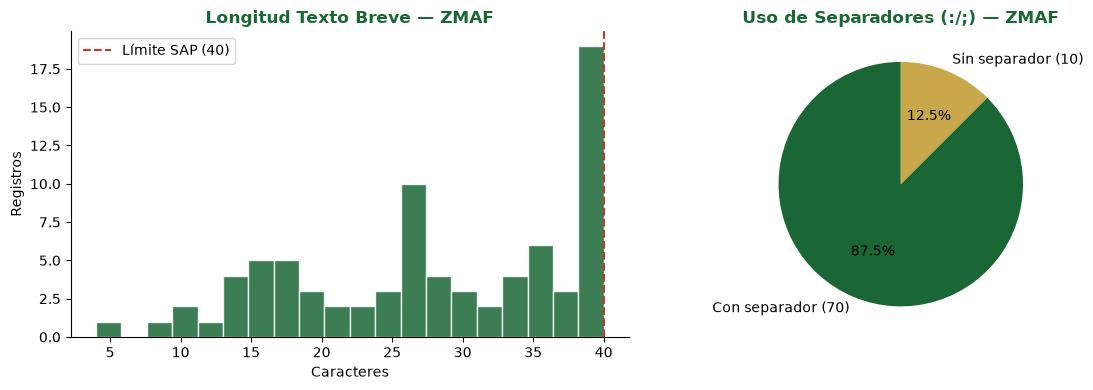

Sin separador estándar: 10  (12.5%)
Longitud promedio: 27.9 chars


In [8]:
col_texto = 'Texto breve de material' if 'Texto breve de material' in df.columns else df.columns[-1]
df['len_texto'] = df[col_texto].astype(str).str.len()

# Separadores
tiene_sep = df[col_texto].astype(str).str.contains(r'[:/;]', regex=True)
sin_sep   = (~tiene_sep).sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma longitud
axes[0].hist(df['len_texto'], bins=20, color=CMI_VERDE, edgecolor='white', alpha=0.85)
axes[0].axvline(40, color=CMI_ROJO, linestyle='--', label='Límite SAP (40)')
axes[0].set_xlabel('Caracteres')
axes[0].set_ylabel('Registros')
axes[0].set_title(f'Longitud Texto Breve — {TIPO}', fontweight='bold', color=CMI_VERDE)
axes[0].legend()
axes[0].spines[['top','right']].set_visible(False)

# Pie separadores
con_sep = len(df) - sin_sep
axes[1].pie([con_sep, sin_sep],
            labels=[f'Con separador ({con_sep:,})', f'Sin separador ({sin_sep:,})'],
            colors=[CMI_VERDE, CMI_ORO], autopct='%1.1f%%',
            startangle=90, textprops={'fontsize':10})
axes[1].set_title(f'Uso de Separadores (:/;) — {TIPO}', fontweight='bold', color=CMI_VERDE)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f'fig6_texto_{TIPO}.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Sin separador estándar: {sin_sep:,}  ({sin_sep/len(df)*100:.1f}%)')
print(f'Longitud promedio: {df["len_texto"].mean():.1f} chars')


## 8. Resumen de Hallazgos — ZMAF

In [9]:
col_texto = 'Texto breve de material' if 'Texto breve de material' in df.columns else df.columns[-1]
dup_mask  = df.duplicated(subset=[col_texto], keep=False)
col_pb    = next((c for c in df.columns if 'PB' in c or 'nivel' in c.lower()), None)
bloq      = (df[col_pb] == 'X').sum() if col_pb else 'N/D'
tiene_sep = df[col_texto].astype(str).str.contains(r'[:/;]', regex=True)
sin_sep   = (~tiene_sep).sum()

print('=' * 60)
print(f'RESUMEN DE HALLAZGOS — EDA {TIPO} M402')
print('=' * 60)
print(f'  Registros analizados:          {len(df):>10,}')
print(f'  Duplicados exactos:            {dup_mask.sum():>10,} ({dup_mask.sum()/len(df)*100:.1f}%)')
print(f'  Bloqueados (PB=X):             {bloq!s:>10}')
print(f'  Sin separador estándar:        {sin_sep:>10,} ({sin_sep/len(df)*100:.1f}%)')
print('=' * 60)


RESUMEN DE HALLAZGOS — EDA ZMAF M402
  Registros analizados:                  80
  Duplicados exactos:                     4 (5.0%)
  Bloqueados (PB=X):                      1
  Sin separador estándar:                10 (12.5%)
